# KKBOX Churn Prediction — Final Model

`05_ml_comparison.ipynb`(ML)와 `05_dl_comparison.ipynb`(DL)의 결과를 바탕으로 **최종 모델을 선정하고, 다시 학습·평가·저장**하는 노트북입니다.

### 선정 결과: **LightGBM (Optuna 튜닝)**

| 구분 | 후보 | 비교 기준 | 결과 |
|---|---|---|---|
| ML | CatBoost / LightGBM / XGBoost | 5-fold CV ROC-AUC | LightGBM 튜닝 0.8708 ≈ CatBoost 튜닝 0.8701 > XGBoost 0.8568 |
| DL | MLP 4종 (Baseline / BN / Dropout / BN+Dropout) | ROC-AUC | BN+Dropout MLP 0.8485 (Test) |
| **ML vs DL** | LightGBM vs BN+Dropout MLP | **같은 Test 20,000건, F1 최대 기준선** | **LightGBM 우위** (아래 5장) |

### 선정 근거
1. **성능**: Test ROC-AUC 0.8719 vs 0.8485 (차이 0.023). CV fold 표준편차(±0.004~0.006)보다 훨씬 큰 차이. 이탈(8.95%) 같은 소수 클래스를 얼마나 잘 잡는지 보여주는 **PR-AUC**도 0.6116 vs 0.5855로 우위.
2. **CatBoost와는 사실상 동점** (CV 차이 0.0007, 표준편차 이내) → 학습 속도가 빠르고 SHAP 해석이 쉬운 **LightGBM** 선택.
3. **해석 가능성**: 피처 중요도·SHAP으로 이탈 요인을 설명할 수 있어 이탈 관리 액션으로 연결하기 쉬움.

> 참고: DL 비교표의 Dropout MLP는 Validation 점수이고, 모델마다 기준선(0.5 / 0.755)이 달라 재현율·F1은 모델끼리 직접 비교하지 않고 ROC-AUC·PR-AUC로 비교함.

# 1. Data Load

In [1]:
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지: 운영체제별 기본 한글 폰트 지정
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호가 네모로 깨지는 것 방지

TODAY = pd.to_datetime('2017-02-28')
df_all = pd.read_csv("../../data/processed/integrated_data.csv")

In [2]:
import easydict

args = easydict.EasyDict()
args.seed = 42
args.target = df_all['is_churn']

In [3]:
# 클래스 비율
df_all['is_churn'].value_counts()
df_all['is_churn'].value_counts() / df_all.shape[0]

# 전체 평균 이탈률: 모든 그래프의 비교 기준선
OVERALL = df_all["is_churn"].mean()  
print(f"전체 이탈률: {OVERALL:.2%}")

전체 이탈률: 8.95%


# 2. Feature Engineering
`05_ml_comparison.ipynb`와 동일한 로직입니다. (그래프 전용 컬럼·탐색용 셀은 제외)

In [4]:
member_cols = ['city', 'bd', 'registered_via', 'registration_init_time']
df_all['has_member'] = (~df_all[member_cols].isna().all(axis=1)).astype(int)
#msno는있지만 다른 정보가 없는사람과 있는사람을 구분하는 컬럼
df_all['has_member'].value_counts()

has_member
1    88648
0    11352
Name: count, dtype: int64

In [5]:
df_all['registration_init_time']= df_all['registration_init_time'].astype('Int64')

In [6]:
df_all['registration_init_time'] = pd.to_datetime(
    df_all['registration_init_time'].astype(str),
    format='%Y%m%d',     # 연4·월2·일2
    errors='coerce',     # 변환 불가 값은 에러 대신 NaN
)

reg = df_all['registration_init_time']
df_all['tenure_date'] = (TODAY- reg).dt.days  #가입 후 경과 일수

In [7]:
df_all['reg_year'] = reg.dt.year                            # 가입 연도

season_map = {3: '봄', 4: '봄', 5: '봄', 6: '여름', 7: '여름', 8: '여름',
              9: '가을', 10: '가을', 11: '가을', 12: '겨울', 1: '겨울', 2: '겨울'}
df_all['reg_season'] = reg.dt.month.map(season_map)         # 결측은 NaN → 10단계에서 채움

# 같은 날 가입 인원. groupby는 결측 키를 기본으로 빼서, members 없는 사람은 NaN
df_all['same_join_day'] = df_all.groupby('registration_init_time')['msno'].transform('count')

In [8]:
# 성별: 결측을 '미입력'이라는 하나의 그룹으로 취급
df_all["gender_status"] = df_all["gender"].fillna("미입력")
df_all["gender_status"].unique()

array(['female', '미입력', 'male'], dtype=object)

In [9]:
# ── 4. 나이 정제 ──
bd = df_all['bd'].astype(float)
df_all['bd_clean'] = bd.where(bd.between(10, 80))           # 10~80세만 남기고 나머지 NaN
df_all['bd_isnan'] = df_all['bd_clean'].isna().astype(int)  # 나이 모름 = 1

# ── 5. 가입 당시 나이 ──
df_all['age_at_reg'] = df_all['bd_clean'] - df_all['tenure_date'] / 365

In [10]:
# ── 6. 도시 ──
df_all['city_miss'] = (df_all['city'] == 1).astype(int)    # city 1(기본값 추정) = 1. NaN은 False → 0

city_int = df_all['city'].fillna(-1).astype(int)            # 결측 → -1 (members 없음)
city_counts = city_int.value_counts()
rare_cities = city_counts[city_counts < 500].index.difference([-1])   # 500명 미만 도시 (-1은 제외)
df_all['city_clean'] = city_int.where(~city_int.isin(rare_cities), 777)  # 희소 도시 → 777(기타)

# ── 7. 가입 경로 결측 ──
df_all['registered_via'] = df_all['registered_via'].fillna(-1).astype(int)   # 결측 → -1

# ── 9. 계절 결측 ──
df_all['reg_season'] = df_all['reg_season'].fillna('unknown')

# ── 10. 범주형 지정 ──
cat_cols = ['registered_via', 'city_clean', 'gender_status', 'reg_season']
df_all[cat_cols] = df_all[cat_cols].astype('category')

In [11]:
# ── 1. 가입 기간으로 나누기 ──
# 30일 미만은 30일로 올려서 나누기 폭주 방지. 가입정보 없으면 NaN

TRANS_START = pd.to_datetime('2015-01-01')
active_days = (TODAY - df_all['registration_init_time'].clip(lower=TRANS_START)).dt.days
active_years = active_days.clip(lower=30) / 365



df_all['trans_per_year']  = df_all['transaction_count'] / active_years   # 1년에 결제한 횟수
df_all['pay_per_year']    = df_all['total_payment'] / active_years       # 1년에 낸 금액
df_all['cancel_per_year'] = df_all['cancel_count'] / active_years        # 1년에 해지한 횟수


# ── 3. 데이터 유무 3부류 ──
df_all['data_group'] = np.select(
    [df_all['has_member'] == 0, df_all['has_log'] == 0],
    ['정보·로그 없음', '로그만 없음'],
    default='둘 다 있음',
)
df_all['data_group'] = df_all['data_group'].astype('category')

In [12]:
def safe_divide(numerator, denominator):
    return numerator / denominator.replace(0, np.nan)


def add_features(data):
    data = data.copy()

    # 0 값 자체가 의미를 가질 수 있는 보조 flag
    data["no_unique_song"] = (data["total_num_unq"] == 0).astype(int)
    data["zero_plan_days"] = (data["last_plan_days"] == 0).astype(int)

    data["avg_payment"] = safe_divide(
        data["total_payment"],
        data["transaction_count"]
    )

    # 이용 로그 관련
    data["avg_daily_secs"] = safe_divide(
        data["total_secs"],
        data["activity_days"]
    )

    data["avg_daily_complete"] = safe_divide(
        data["total_num_100"],
        data["activity_days"]
    )

    data["avg_daily_unq"] = safe_divide(
        data["total_num_unq"],
        data["activity_days"]
    )

    data["complete_per_unq"] = safe_divide(
        data["total_num_100"],
        data["total_num_unq"]
    )

    # 결제 효율 관련
    data["payment_per_plan_day"] = safe_divide(
        data["avg_payment"],
        data["last_plan_days"]
    )

    return data


df_all = add_features(df_all)

# 3. Final Features & Train/Test Split
최종 피처 33개 (범주형 3 + 수치형 30). 선정 사유는 `05_ml_comparison.ipynb`의 피처 조합 비교 메모 참고.

In [13]:
ids = ['msno']
targets = 'is_churn'

categories = [
    'registered_via', 'city_clean', 'gender_status',
    #'reg_season',
]

numbers = [
    # members (본인)
    'has_member', 'tenure_date', 'same_join_day',
    'bd_clean', 'bd_isnan', 'age_at_reg', 'city_miss',

    # 거래 (팀 통합)
    'transaction_count', 'cancel_count', 'total_payment',
    'last_auto_renew', 'last_is_cancel', 'last_plan_days',
    'cancel_on_last_date', 'has_transaction',

    # 로그 (팀 통합)
    'activity_days', 'total_secs', 'total_num_100', 'total_num_unq',
    'days_since_last_log', 'has_log',

    #members 결합 (본인)
    'trans_per_year', #'pay_per_year',

     # 소희 (제외 여부는 아래 '피처 조합 비교' 결과로 판단 → 결과표 아래 메모에 사유 기록)
     #'inactive_7days', 'completed_per_hour', 'cancel_rate',
     #'no_auto_renew_low_activity', 'long_tenure_low_activity',

    # # 선아
    'avg_payment', 
    'avg_daily_secs', 'avg_daily_complete', 'avg_daily_unq',
    'complete_per_unq', 'payment_per_plan_day',
    'no_unique_song', 'zero_plan_days',
]

all_col = categories + numbers
print(f"범주형 {len(categories)}개 + 수치형 {len(numbers)}개 = {len(all_col)}개")   # 현재 3 + 30 = 33개

범주형 3개 + 수치형 30개 = 33개


In [14]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(df_all.index, random_state=args.seed,
                                       test_size=0.2, stratify=df_all[targets])

# ── 분할 후 재계산: 테스트 정보가 섞이지 않도록 학습 데이터로만 계산 ──
# (1) same_join_day: 학습 데이터에서 같은 날 가입한 인원 수
join_cnt = df_all.loc[train_idx].groupby('registration_init_time')['msno'].count()
sjd = df_all['registration_init_time'].map(join_cnt)
df_all['same_join_day'] = sjd.where(df_all['registration_init_time'].isna(), sjd.fillna(0))

# (2) city_clean: 학습 데이터 기준 400명 미만 도시 → 777(기타)
city_int = df_all['city'].fillna(-1).astype(int)
city_cnt_tr = city_int.loc[train_idx].value_counts()
keep_cities = city_cnt_tr[city_cnt_tr >= 400].index.union([-1])
df_all['city_clean'] = city_int.where(city_int.isin(keep_cities), 777)

df_all[categories] = df_all[categories].astype('category')

x_train, x_test = df_all.loc[train_idx, all_col], df_all.loc[test_idx, all_col]
y_train, y_test = df_all.loc[train_idx, targets], df_all.loc[test_idx, targets]

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((80000, 33), (80000,), (20000, 33), (20000,))

# 4. Final Model — LightGBM (Tuned)
`05_ml_comparison.ipynb`의 Optuna 탐색 결과(최적 파라미터)를 고정해서 train 80,000건으로 다시 학습합니다.

In [15]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

from common.models import ModelType
from common.evaluate import get_score, evaluate
from common.cross_validation import fit_params_for

In [16]:
BEST_NAME = "lgb"
BEST_PARAMS = {
    'n_estimators': 200,
    'learning_rate': 0.02008331932698382,
    'num_leaves': 53,
    'min_child_samples': 41,
}

final_model = ModelType[BEST_NAME].create(args.seed, **BEST_PARAMS)
final_model.fit(x_train, y_train, **fit_params_for(BEST_NAME, categories))

score = evaluate(final_model, [x_train, y_train], [x_test, y_test])
display(pd.DataFrame({
    k: {"ROC-AUC": s["auc_score"], "PR-AUC": s["pr_auc"]} for k, s in score.items()
}).T.round(4))
print("※ 05_ml_comparison 기록: test ROC-AUC 0.8719 / PR-AUC 0.6116 — 같으면 재현 성공")

,ROC-AUC,PR-AUC
train_score,0.9071,0.6756
test_score,0.8719,0.6116


※ 05_ml_comparison 기록: test ROC-AUC 0.8719 / PR-AUC 0.6116 — 같으면 재현 성공


## Threshold Tuning
테스트 데이터를 보지 않도록 **학습 데이터 5-fold 교차검증 예측**으로 F1이 최대가 되는 기준선을 정합니다.

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=args.seed)
proba_cv = cross_val_predict(ModelType[BEST_NAME].create(args.seed, **BEST_PARAMS),
                             x_train, y_train, cv=skf, method="predict_proba",
                             params=fit_params_for(BEST_NAME, categories))[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, proba_cv)
f1 = 2 * precision * recall / (precision + recall + 1e-9)
best = f1[:-1].argmax()
TH = float(thresholds[best])
print(f"기준선: {TH:.3f} (CV 재현율 {recall[best]:.3f}, 정밀도 {precision[best]:.3f})")

기준선: 0.282 (CV 재현율 0.531, 정밀도 0.633)


# 5. Final Evaluation & ML vs DL Comparison

In [18]:
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, classification_report, confusion_matrix)

proba_te = final_model.predict_proba(x_test)[:, 1]

def summarize(y, proba, th):
    pred = (proba >= th).astype(int)
    return {"ROC-AUC": roc_auc_score(y, proba), "PR-AUC": average_precision_score(y, proba),
            "기준선": th, "재현율": recall_score(y, pred), "정밀도": precision_score(y, pred),
            "F1": f1_score(y, pred)}

lgb_05 = summarize(y_test, proba_te, 0.5)
lgb_th = summarize(y_test, proba_te, TH)

# DL 최고 모델(BN+Dropout MLP) 결과: 05_dl_comparison.ipynb 셀 176·178 (같은 test 20,000건, 검증셋 F1 최대 기준선)
mlp = {"ROC-AUC": 0.8485, "PR-AUC": 0.5855, "기준선": 0.7548,
       "재현율": 0.5536, "정밀도": 0.5742, "F1": 0.5637}

final_cmp = pd.DataFrame({
    "LightGBM (기준선 0.5)": lgb_05,
    f"LightGBM (기준선 {TH:.3f}) ★최종": lgb_th,
    "MLP BN+Dropout (DL 1위)": mlp,
}).round(4)
display(final_cmp)

,LightGBM (기준선 0.5),LightGBM (기준선 0.282) ★최종,MLP BN+Dropout (DL 1위)
ROC-AUC,0.8719,0.8719,0.8485
PR-AUC,0.6116,0.6116,0.5855
기준선,0.5000,0.2824,0.7548
재현율,0.4106,0.5363,0.5536
정밀도,0.7895,0.6328,0.5742
F1,0.5402,0.5806,0.5637


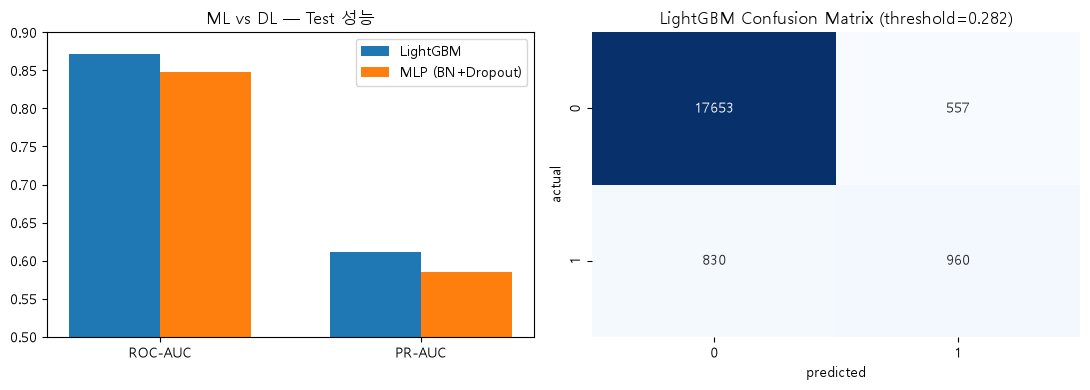

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     18210
           1       0.63      0.54      0.58      1790

    accuracy                           0.93     20000
   macro avg       0.79      0.75      0.77     20000
weighted avg       0.93      0.93      0.93     20000



In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metrics = ["ROC-AUC", "PR-AUC"]
x = np.arange(len(metrics)); w = 0.35
axes[0].bar(x - w/2, [lgb_th[m] for m in metrics], w, label="LightGBM")
axes[0].bar(x + w/2, [mlp[m] for m in metrics], w, label="MLP (BN+Dropout)")
axes[0].set_xticks(x, metrics); axes[0].set_ylim(0.5, 0.9); axes[0].legend()
axes[0].set_title("ML vs DL — Test 성능")

sns.heatmap(confusion_matrix(y_test, (proba_te >= TH).astype(int)), annot=True, fmt="d",
            cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("actual")
axes[1].set_title(f"LightGBM Confusion Matrix (threshold={TH:.3f})")
plt.tight_layout(); plt.show()

print(classification_report(y_test, (proba_te >= TH).astype(int)))

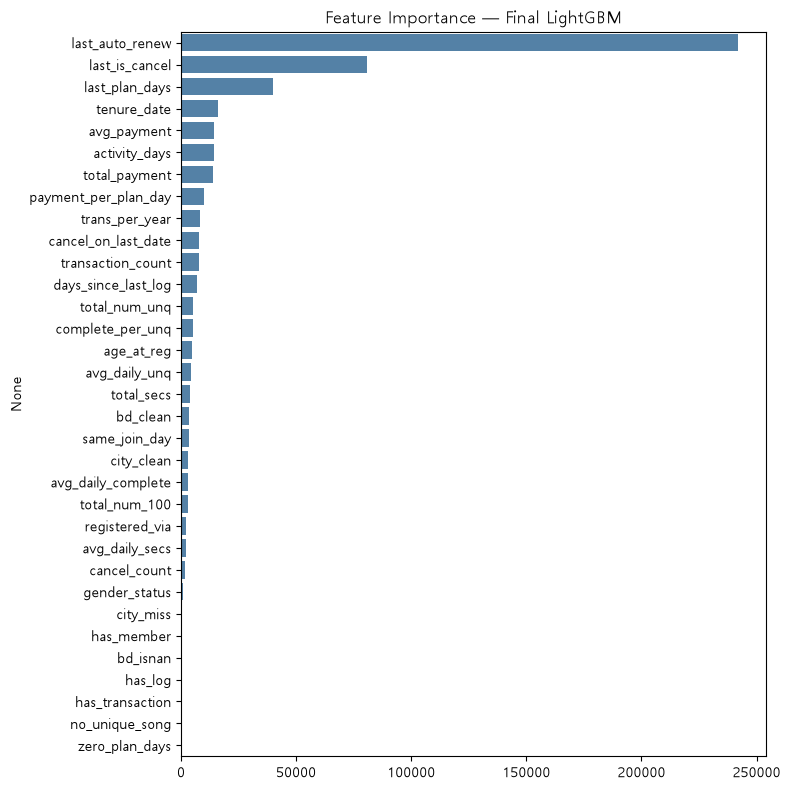

In [20]:
imp = pd.Series(final_model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 8))
sns.barplot(x=imp.values, y=imp.index, color="steelblue")
plt.title("Feature Importance — Final LightGBM")
plt.tight_layout(); plt.show()

**최종 결론**
- 최종 모델: **LightGBM (n_estimators=200, learning_rate≈0.020, num_leaves=53, min_child_samples=41)**
- 운영 기준선: **F1 최대 기준선(약 0.28)** — 기준선 0.5보다 재현율이 0.41 → 0.54로 오르고, 정밀도 0.63 유지
- DL 최고 모델(BN+Dropout MLP) 대비 ROC-AUC +0.023, PR-AUC +0.026
- 한계: lgb `learning_rate` 최적값이 탐색 범위 하한(0.02)에 붙어 있음 → 범위를 넓혀 재탐색할 여지 있음 (튜닝 효과 자체는 +0.0016으로 오차 범위 안)

# 6. Save Final Model
새 데이터에 같은 전처리를 적용하려면 모델뿐 아니라 **기준선·피처 순서·범주 레벨·학습 데이터 기준값**도 필요하므로 한 파일에 같이 저장합니다.

In [21]:
import joblib

MODEL_DIR = Path("../../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "final_model_lgb.pkl"

bundle = {
    "model": final_model,
    "model_name": "LightGBM (tuned)",
    "params": BEST_PARAMS,
    "threshold": TH,
    "features": all_col,
    "categories": categories,
    "category_levels": {c: x_train[c].cat.categories.tolist() for c in categories},
    "keep_cities": keep_cities.tolist(),   # city_clean 변환 기준
    "join_cnt": join_cnt,                  # same_join_day 계산 기준
    "today": TODAY,
    "test_score": final_cmp[f"LightGBM (기준선 {TH:.3f}) ★최종"].to_dict(),
}
joblib.dump(bundle, MODEL_PATH)
print("저장 완료:", MODEL_PATH.resolve())

저장 완료: C:\dev\project\2차 단위 프로젝트\2nd-feature-final-model\models\final_model_lgb.pkl


## Load Check
저장한 파일을 다시 불러와 같은 점수가 나오는지 확인합니다.

In [22]:
loaded = joblib.load(MODEL_PATH)

x_chk = x_test[loaded["features"]].copy()
for c in loaded["categories"]:
    x_chk[c] = pd.Categorical(x_chk[c].astype(object), categories=loaded["category_levels"][c])

proba_chk = loaded["model"].predict_proba(x_chk)[:, 1]
pred_chk = (proba_chk >= loaded["threshold"]).astype(int)

print(f"ROC-AUC {roc_auc_score(y_test, proba_chk):.4f} | 재현율 {recall_score(y_test, pred_chk):.4f} "
      f"| 정밀도 {precision_score(y_test, pred_chk):.4f}")
assert np.allclose(proba_chk, proba_te), "저장 전후 예측이 다릅니다"
print("✅ 저장 전후 예측 일치")

ROC-AUC 0.8719 | 재현율 0.5363 | 정밀도 0.6328
✅ 저장 전후 예측 일치
